# Section 1 — Universe, factors, baskets

*Which stocks carry AI-related return co-movement beyond the Mag-7, and how should the index be grouped accordingly?*

This notebook builds the five baskets that the rest of the study works with: the Mag-7 (both Alphabet share classes) carved out by name, and the remaining S&P 100 names double-sorted on AI factor loading and 12-1 momentum. The functions live in `src/quiet_index`; the notebook calls them, shows what they return and explains what the results mean. Definitions are in `README.md`.

Everything is as of 30 September 2026. Prices are Yahoo Finance adjusted closes pulled on 3 October 2026, and index weights are from the iShares OEF holdings file dated 1 October 2026.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quiet_index import config as cfg
from quiet_index import data, pipeline, plots

pd.set_option("display.width", 200)
study_data = data.load_study_data() #cached prices, returns and index weights, cut off at the study end date

section_1 = pipeline.run_section_1(study_data) #loadings, basket assignments and basket returns at every formation date
tables = section_1["tables"]

## 1.1 Universe and data quality

Current S&P 100 membership, held fixed over the study period. The table below lists the tickers that do not have a full price history back to January 2018.

In [2]:
audit = tables["s1_data_audit"]
print(f"{len(audit)} tickers, {audit['full_history'].sum()} with a full history, {int(audit['gaps_after_start'].sum())} missing prices after a stock's first trading day")
audit[~audit["full_history"]][["first_date", "n_prices", "gaps_after_start"]] #the four names listed after January 2018

101 tickers, 97 with a full history, 0 missing prices after a stock's first trading day


,first_date,n_prices,gaps_after_start
ticker,,,
GEV,2024-03-27,630,0
PLTR,2020-09-30,1507,0
SNDK,2025-02-13,409,0
UBER,2019-05-10,1858,0


The universe is 101 tickers, which is 100 companies with Alphabet counted twice. Ninety-seven of them have a price on every trading day since January 2018. The other four listed during the study period (UBER in May 2019, PLTR in September 2020, GEV in March 2024 and SNDK in February 2025), and each one only enters the sort once it has a year of prices behind it, because 12-1 momentum needs a price from 252 trading days earlier. No ticker has a missing price after its first trading day, so the return series need no filling or interpolation.

Holding today's membership fixed over history means that every stock in the sample is a survivor, which biases average returns upward. That is acceptable for a study of how risk is distributed, and it is the reason no performance claims are made anywhere in this repository.

## 1.2 Factor estimation

*How much does each stock move with the market, and how much with AI-specific news beyond the market?*

Two-factor model (market + AI), estimated in two stages over a trailing 252-day window at each formation date:

1. Regress SMH on SPY and keep the residual $\varepsilon_{SMH}$ — the AI factor with the market removed.
2. Regress each stock on SPY → market beta $\beta_i$ and residual $\varepsilon_i$.
3. Regress $\varepsilon_i$ on $\varepsilon_{SMH}$ → AI loading $\lambda_i$.

By Frisch–Waugh–Lovell, $\lambda_i$ equals the SMH coefficient in a joint regression of the stock on SPY and SMH. The cell below confirms that on one stock, and checks that a known high-beta name lands where it should.

In [3]:
from quiet_index import factors

qe = section_1["latest_quarter_end"]
loadings = tables["s1_loadings_latest"] #latest formation's table, for the cross-section analysis
pos = study_data["members_returns"].index.get_loc(qe)
window = study_data["members_returns"].index[pos - cfg.ESTIMATION_WINDOW + 1 : pos + 1] #trailing 252 daily returns

joint_lambda = factors.joint_regression_ai_beta(study_data["members_returns"].loc[window, "CAT"],
                                                study_data["spy_returns"].reindex(window),
                                                study_data["benchmark_returns"].loc[window, cfg.AI_PROXY])
print(f"{len(section_1['loadings_by_qe'])} formations, first {min(section_1['loadings_by_qe']).date()}, last {qe.date()}")
print(f"CAT two-stage lambda {loadings.loc['CAT', 'ai_beta']:.6f}, joint regression {joint_lambda:.6f}")
print(f"NVDA market beta {loadings.loc['NVDA', 'beta_mkt']:.2f} (expected in the 1.5 to 2.5 range)")

31 formations, first 2019-03-29, last 2026-09-30
CAT two-stage lambda 0.642713, joint regression 0.642713
NVDA market beta 1.88 (expected in the 1.5 to 2.5 range)


## 1.3 Cross-section at the latest formation

*What do the AI loadings look like today, and how far do they reach beyond the Mag-7?*

lambda above 0: 19 names outside the Mag-7, 17.3% of index weight
lambda above 0.5: 13 names outside the Mag-7, 14.4% of index weight
lambda above 1.0: 6 names outside the Mag-7, 8.1% of index weight
median lambda outside the Mag-7: -0.22


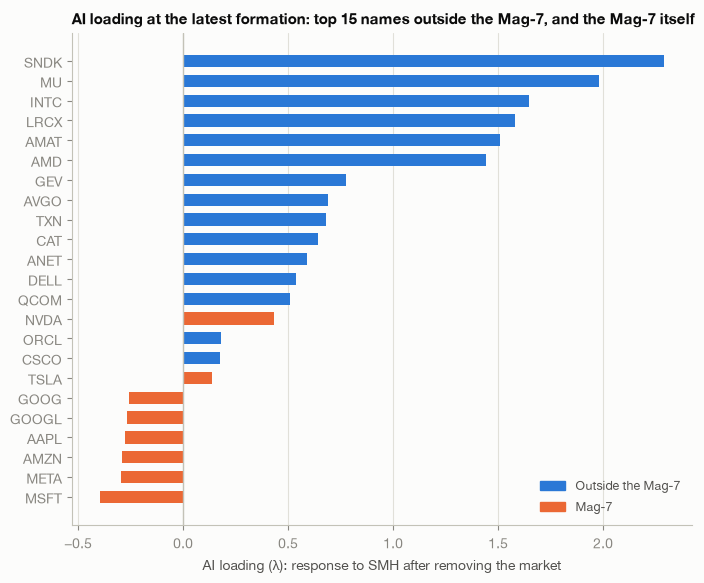

In [4]:
outside_mag7 = loadings[loadings["basket"] != "M7"]
for threshold in [0, 0.5, 1.0]:
    above = outside_mag7[outside_mag7["ai_beta"] > threshold]
    print(f"lambda above {threshold}: {len(above)} names outside the Mag-7, {above['weight'].sum():.1%} of index weight")
print(f"median lambda outside the Mag-7: {outside_mag7['ai_beta'].median():.2f}")

plots.plot_ai_loadings(loadings);

The six highest loadings all belong to semiconductor and memory companies (SNDK 2.29, MU 1.98, INTC 1.64, LRCX 1.58, AMAT 1.51, AMD 1.44). Below them sits a second group in which the link to AI spending runs through power equipment, networking and hardware rather than through chips themselves (GEV, AVGO, TXN, CAT, ANET, DELL, QCOM, all between 0.5 and 0.8). In total 13 names outside the Mag-7 have a loading above 0.5, and together they carry 14.4% of index weight. Nineteen have a positive loading at all, carrying 17.3%.

Inside the Mag-7 only NVDA (0.43) and TSLA (0.14) load positively. The other five companies sit between −0.26 and −0.40. This follows from how $\lambda$ is constructed and should not be read as saying that Microsoft or Alphabet have no AI exposure. The market factor is SPY, and the Mag-7 are the largest weights in SPY, so whatever these companies have in common with each other is already inside the market return and is removed in the first regression. What remains in $\lambda$ is co-movement with semiconductors over and above the market, and on that measure the large platform companies behave more like the rest of the index than like chip makers.

So the answer to the second research question is that AI-related co-movement does extend beyond the Mag-7, but into a narrow group: roughly a dozen names, most of them in the semiconductor supply chain, holding about a seventh of the index. It is also worth being clear about what "AI high" means in the sort that follows. The median loading across the 93 names outside the Mag-7 is −0.22, so a stock with a small negative loading (JPM and XOM are examples) lands in the "AI high" half. The label means *above-median AI loading*, and it does not mean AI-exposed.

## 1.4 Rank correlation of the sorting variables

Spearman correlation: do the three variables order the stocks the same way? A double sort works best when the two sorting variables are close to independent, so this is checked at every formation and not only at the latest one.

In [5]:
rank_correlations = tables["s1_rank_correlations"]
pd.concat([rank_correlations.agg(["mean", "min", "max"]), rank_correlations.tail(4)]).round(2) #summary across all formations, then the last four

,beta_vs_ai,beta_vs_momentum,ai_vs_momentum
mean,0.64,0.09,0.14
min,-0.09,-0.76,-0.66
max,0.91,0.68,0.75
2025-12-31,0.87,0.29,0.39
2026-03-31,0.75,0.38,0.67
2026-06-30,0.44,0.41,0.74
2026-09-30,0.47,0.30,0.67


Across the 31 formations the rank correlation between AI loading and momentum averages 0.14, which is close enough to independent for a double sort to separate the two effects. The average hides a wide range, though, from −0.66 to 0.75, and the last three formations sit between 0.67 and 0.74. At present the high-AI names are also the high-momentum names. That shows up directly in the basket counts in the next section: 35 and 34 names on the diagonal of the 2×2 grid against 12 and 12 off it.

Market beta and AI loading are also related, with an average rank correlation of 0.64. The loading is measured after the market has been removed from each stock's returns, so this is not a mechanical overlap, but it does mean that high-$\lambda$ stocks tend to be high-beta stocks, and part of what the AI baskets show in Section 2 is the ordinary effect of holding high-beta names.

## 1.5 Basket formation

Mag-7 by name; everything else by the 2×2 median sort, repeated at every quarter-end using only data available on that date. Each formation's assignment governs the following quarter.

In [6]:
membership = tables["s1_membership_summary"].reset_index()
latest_membership = membership[membership["quarter_end"] == membership["quarter_end"].max()].set_index("basket")[["names", "capital_share"]]
latest_membership.assign(capital_share=lambda t: (t["capital_share"] * 100).round(1)) #names and percent of index capital at the latest formation

,names,capital_share
basket,,
M7,8,46.6
AI_HI_MOM_HI,35,23.4
AI_HI_MOM_LO,12,8.7
AI_LO_MOM_HI,12,7.4
AI_LO_MOM_LO,34,13.8


In [7]:
membership.groupby("basket")[["names", "capital_share"]].agg(["min", "mean", "max"]).round(3).reindex(cfg.BASKETS) #the same two columns across all 31 formations

names             capital_share              
               min    mean max           min   mean    max
basket                                                    
M7               8   8.000   8         0.466  0.472  0.477
AI_HI_MOM_HI    11  24.935  37         0.074  0.178  0.279
AI_HI_MOM_LO     8  20.839  35         0.034  0.114  0.204
AI_LO_MOM_HI     8  20.839  35         0.058  0.119  0.196
AI_LO_MOM_LO    10  24.226  37         0.057  0.116  0.180

In [8]:
turnover = tables["s1_turnover"]
turnover[["share_of_names_moved", "share_of_capital_moved"]].agg(["mean", "min", "max"]).round(3) #share of ex-Mag-7 names and capital that change basket between formations

,share_of_names_moved,share_of_capital_moved
mean,0.323,0.311
min,0.187,0.148
max,0.456,0.497


At the latest formation the Mag-7 holds 46.6% of index capital in eight tickers. The AI-high, momentum-high basket is the largest of the other four at 23.4% in 35 names, followed by AI-low, momentum-low at 13.8% in 34 names. The two off-diagonal baskets hold 8.7% and 7.4% in 12 names each.

Two things about the history matter for how the later results are read. First, the off-diagonal baskets have held as few as 8 names, so their return series are noisier than the others and their risk estimates deserve less confidence. Second, on average 32% of the names outside the Mag-7 change basket from one quarter to the next (between 19% and 46%), representing 31% of the capital outside the Mag-7. With turnover of that size a basket is best thought of as a characteristic at a point in time. The "AI high, momentum high" return series is the return to holding whichever stocks had that profile each quarter, and the companies in it in 2019 are largely different from the companies in it today.

## 1.6 Basket return series

Basket return = capital-weighted average of member returns, re-normalized each day across the members that have a return that day. Member log returns are converted to simple returns before averaging and the result is converted back, because a portfolio's return is the weighted average of its members' simple returns and not of their log returns.

In [9]:
basket_daily_returns = section_1["basket_daily_returns"]
print(f"{len(basket_daily_returns)} trading days, {basket_daily_returns.index[0].date()} to {basket_daily_returns.index[-1].date()}")
tables["s1_basket_summary"].round(3)

1886 trading days, 2019-04-01 to 2026-09-30


,annualized_mean_return,annualized_volatility
basket,,
M7,0.334,0.303
AI_HI_MOM_HI,0.263,0.288
AI_HI_MOM_LO,0.207,0.262
AI_LO_MOM_HI,0.186,0.180
AI_LO_MOM_LO,0.154,0.178


In [10]:
tables["s1_basket_correlations"].round(2) #pairwise correlations of daily basket returns over the full history

,M7,AI_HI_MOM_HI,AI_HI_MOM_LO,AI_LO_MOM_HI,AI_LO_MOM_LO
basket,,,,,
M7,1.00,0.80,0.76,0.51,0.47
AI_HI_MOM_HI,0.80,1.00,0.80,0.59,0.53
AI_HI_MOM_LO,0.76,0.80,1.00,0.63,0.68
AI_LO_MOM_HI,0.51,0.59,0.63,1.00,0.75
AI_LO_MOM_LO,0.47,0.53,0.68,0.75,1.00


Annualized volatility falls in two steps: about 30% for the Mag-7, 26% to 29% for the two AI-high baskets, and 18% for the two AI-low baskets. The correlations tell the same story from a different angle. The Mag-7 has a correlation of 0.80 and 0.76 with the two AI-high baskets but only 0.51 and 0.47 with the two AI-low baskets, and the two AI-low baskets have a correlation of 0.75 with each other. The AI split therefore divides the index into two blocks that behave differently, whereas the momentum split does comparatively little inside each block (0.80 between the two AI-high baskets, 0.75 between the two AI-low baskets).

The mean returns in the first table are reported for completeness. They come from a universe of survivors, and nothing in this study relies on them as forecasts.

## 1.7 Validation

Three checks on whether the baskets are built correctly and whether they would survive a different way of forming them.

### 1.7.1 Synthetic Mag-7 against MAGS

MAGS is a listed ETF that holds the seven companies at roughly equal weight. If the Mag-7 basket here is built correctly, an equal-weighted version of it should track MAGS closely over the period since MAGS listed.

overlap: 2023-04-12 to 2026-09-30, 871 days


,correlation,tracking_error,annualized_volatility,cumulative_log_return,cumulative_gap_vs_mags
series,,,,,
Cap-weighted synthetic,0.954,0.077,0.245,1.299,-0.197
Equal-weighted synthetic,0.986,0.043,0.255,1.206,-0.104
MAGS,1.000,0.000,0.257,1.102,0.000


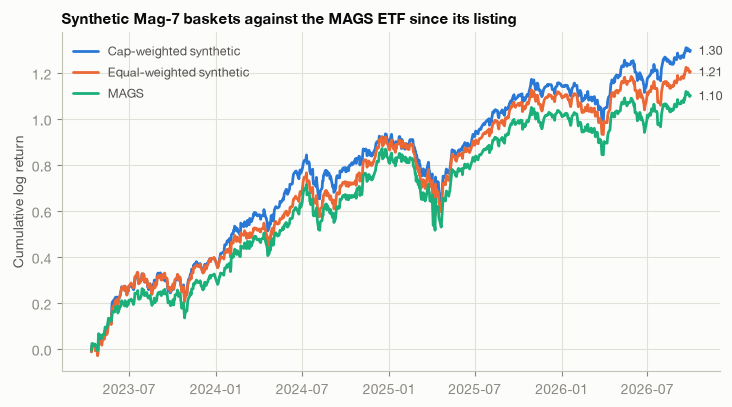

In [11]:
print(f"overlap: {section_1['mags_cumulative'].index[0].date()} to {section_1['mags_cumulative'].index[-1].date()}, {len(section_1['mags_cumulative'])} days")
display(tables["s1_mags_comparison"].round(3))
plots.plot_mags(section_1["mags_cumulative"]);

Over the 871 days of overlap the equal-weighted synthetic basket has a daily correlation of 0.986 with MAGS and a tracking error of 4.3% a year, against 0.954 and 7.7% for the cap-weighted basket used in the study. For the purpose of this check, which is confirming that the basket return series is constructed correctly, that is sufficient.

The cumulative returns do differ. MAGS finishes 0.20 behind the cap-weighted basket in log terms (1.10 against 1.30). Roughly half of that gap, 0.09, is the weighting scheme: holding the seven at index weights rather than equal weights was worth that much over this period. The remaining 0.10, about 3% a year, is not explained by weighting. The fund's fee, the cost of the swaps it uses for part of its exposure and its quarterly rather than daily rebalancing are all candidates, and this study does not attempt to separate them.

### 1.7.2 NVDA as the AI proxy

The same loadings re-estimated with NVDA's market residual in place of SMH's.

In [12]:
proxy_robustness = tables["s1_proxy_robustness"]
pd.concat([proxy_robustness.agg(["mean", "min", "max"]), proxy_robustness.tail(1)]).round(3) #rank correlation of the two lambdas, and share of names on the same side of the median

,rank_correlation,same_side_of_median
mean,0.879,0.857
min,0.506,0.699
max,0.962,0.956
2026-09-30,0.663,0.785


Across the 31 formations the two versions of $\lambda$ have an average rank correlation of 0.88, and on average 86% of names fall on the same side of the median whichever proxy is used. At the latest formation the agreement is weaker, with a rank correlation of 0.66 and 79% of names on the same side. The AI-high and AI-low halves are therefore mostly, but not entirely, insensitive to the choice of proxy, and roughly one name in five would currently change halves if NVDA were used instead of SMH.

### 1.7.3 Clustering cross-check

Do groups found by a clustering algorithm agree with the rule-based baskets? The adjusted Rand index is 1 when two sets of labels are identical and close to 0 when they agree no more than chance would produce.

In [13]:
clustering = tables["s1_clustering_rand_index"]
pd.concat([clustering.agg(["mean", "min", "max"]), clustering.tail(1)]).round(2)

,kmeans_on_sorting_ranks,ward_on_sorting_ranks,hierarchical_on_residual_correlations
mean,0.71,0.57,0.17
min,0.48,0.38,0.02
max,0.94,0.83,0.33
2026-09-30,0.62,0.67,0.02


When the clustering is run on the same two characteristics the sort uses (the ranks of AI loading and momentum), k-means reproduces the rule-based labels with an average adjusted Rand index of 0.71, and Ward hierarchical clustering with 0.57. The four quadrants are therefore a reasonable way to partition that characteristic space, in the sense that an algorithm that knows nothing about medians lands on broadly similar groups.

When the clustering is run instead on how the stocks' returns move together after the market has been removed, the agreement falls to 0.17 on average and 0.02 at the latest formation, which is no better than chance. This is the more important result for interpretation. The baskets are a sort on two characteristics. They are not groups of stocks that naturally move together, and the stocks inside one basket can have little in common beyond their position relative to two medians.

## Conclusions

The index divides into five baskets whose return series start on 1 April 2019 and run for 1,886 trading days. The construction has been checked against a listed ETF, against an alternative AI proxy and against two clustering methods, and the checks support the mechanics while placing clear limits on the interpretation.

On the research question this section addresses, AI-related co-movement beyond the market does reach outside the Mag-7, but narrowly. Thirteen names, most of them in the semiconductor supply chain, have a loading above 0.5 and together hold 14.4% of the index. Most of the Mag-7 do not load positively on this factor at all once the market is removed, because their common behaviour is already in the market factor.

Three caveats carry forward into Section 2. "AI high" means above the median, and the median is currently negative. The AI and momentum sorts are close to independent on average but strongly aligned at present (rank correlation 0.67), which leaves the two off-diagonal baskets thin. And about a third of names change basket each quarter, so a basket's history is the history of a characteristic and not of a fixed set of companies.